In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [28]:
data = load_breast_cancer()
X = data.data
y = data.target

X = pd.DataFrame(X, columns = data.feature_names)
y = pd.DataFrame(y, columns = ['target'])

data = pd.concat([X, y], axis = 1)

In [1]:
# for feature in X.columns:
#     for targ in y['target'].unique():
#         df = data[data['target'] == targ]
#         plt.hist(df[feature],bins = 20, alpha = 0.3, label = targ)
#         plt.title(feature)
#         plt.legend()
#     plt.show()

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter = 5000))
])

param_grid = [
    {
    'model__penalty' : ['l1'],
    'model__C' : [0.01,0.1,1.,10.],
    'model__solver' : ['liblinear'],
    'model__class_weight' : ['balanced']
    },
    {
    'model__penalty' : ['l2'],
    'model__C' : [0.01,0.1,1.,10.],
    'model__solver' : ['lbfgs'],
    'model__class_weight' : ['balanced']
    },
    {
    'model__penalty' : ['elasticnet'],
    'model__C' : [0.01,0.1,1.,10.],
    'model__l1_ratio' : np.linspace(0.1,0.9,10),
    'model__solver' : ['saga'],
    'model__class_weight' : ['balanced']
    }
]

grid = GridSearchCV(pipe, param_grid, cv = StratifiedKFold(n_splits = 5,shuffle=True,random_state = 42), scoring = 'accuracy',n_jobs=-1)
grid.fit(X_train,np.array(y_train).ravel())
print(grid.best_params_)
model = grid.best_estimator_
coef = model.named_steps['model'].coef_
coef = pd.Series(coef.ravel(), index = X.columns)
coef = coef.sort_values(ascending = False)
print(coef)


{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__l1_ratio': np.float64(0.18888888888888888), 'model__penalty': 'elasticnet', 'model__solver': 'saga'}
fractal dimension error    0.193966
compactness error          0.158243
symmetry error             0.128709
mean fractal dimension     0.067482
mean symmetry              0.000000
mean compactness           0.000000
smoothness error           0.000000
worst fractal dimension    0.000000
concavity error            0.000000
concave points error       0.000000
texture error              0.000000
worst compactness         -0.059994
mean smoothness           -0.077957
mean concavity            -0.272087
perimeter error           -0.277678
area error                -0.283433
mean area                 -0.316633
mean perimeter            -0.333556
mean radius               -0.348976
worst concavity           -0.362954
mean texture              -0.375429
worst smoothness          -0.384672
worst area                -0.418897
worst symm

0.9824561403508771


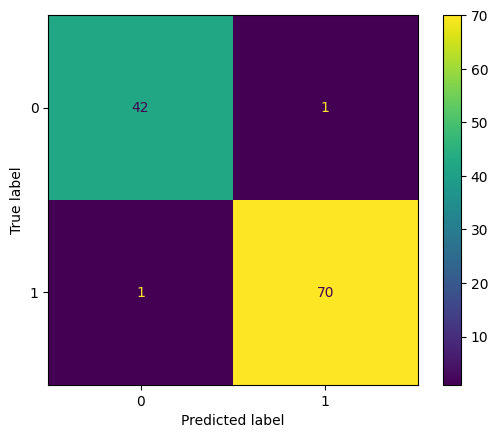

In [33]:
y_preds = model.predict(X_test)
print(accuracy_score(y_test, y_preds))
conf = confusion_matrix(y_test, y_preds)
ConfusionMatrixDisplay(confusion_matrix = conf).plot()